In [21]:
# This code is heavily inspired by https://github.com/gingsmith/fmtl

In [22]:
import numpy as np
from scipy.linalg import sqrtm, inv
from data import CaseHFL_Heterogeneous, CaseHFL
from sklearn.preprocessing import StandardScaler
from typing import List
import matplotlib.pyplot as plt

In [23]:
def compute_rmse(X, Y, W):
    errors = []
    for t in range(len(X)):
        preds = np.dot(X[t], W[:, t])
        errors.append(np.sqrt(np.mean((Y[t] - preds)**2)))
    return np.mean(errors)

In [24]:
def compute_primal(X_train, Y_train, W, Omega, lam):
    m = len(X_train)
    total_loss = 0
    for t in range(m):
        preds = np.dot(X_train[t], W[:, t])
        total_loss += np.mean((Y_train[t] - preds)**2)
    
    reg_term = (lam / 2.0) * np.trace(W @ Omega @ W.T)
    
    return (total_loss / m) + reg_term

def compute_dual(alpha, Ytrain, W, Omega, lam):
    m = len(alpha)
    dual_loss_term = 0
    for t in range(m):
        alpha_t = alpha[t]
        y_t = Ytrain[t]
        
        dual_loss_term += np.mean(0.5 * alpha_t**2 + alpha_t * y_t)
        
    reg_dual = (lam / 2.0) * np.trace(W @ Omega @ W.T)
    
    return -(reg_dual + (dual_loss_term / m))

In [25]:
def run_mocha(X_train, Y_train, X_validation, Y_validation, lam, opts):
    num_tasks = len(X_train) 
    num_features = X_train[0].shape[1] 
    
    W = np.zeros((num_features, num_tasks))
    alpha = [np.zeros(Y_train[t].shape[0]) for t in range(num_tasks)]
    Sigma = np.eye(num_tasks) * (1.0 / num_tasks)
    Omega = inv(Sigma)
    
    num_data_points = np.array([len(Y_train[t]) for t in range(num_tasks)])
    spectral_scaling_param = 1.0
    
    num_metrics = opts['mocha_inner_iters'] if opts.get('w_update') else opts['mocha_outer_iters']
    rmse_history = np.zeros(num_metrics)
    primal_objs = np.zeros(num_metrics)
    dual_objs = np.zeros(num_metrics)

    for h in range(opts['mocha_outer_iters']):
        if not opts.get('w_update'):
            rmse_history[h] = compute_rmse(X_validation, Y_validation, W)
            primal_objs[h] = compute_primal(X_train, Y_train, W, Omega, lam)
            dual_objs[h] = compute_dual(alpha, Y_train, W, Omega, lam)

        # Update weights
        for hh in range(opts['mocha_inner_iters']):
            if opts.get('systems_heterogeneity'):
                sys_iters = (opts['top'] - opts['bottom']) * np.random.rand(num_tasks) + opts['bottom']
            
            if opts.get('w_update'):
                rmse_history[hh] = compute_rmse(X_validation, Y_validation, W)
                primal_objs[hh] = compute_primal(X_train, Y_train, W, Omega, lam)
                dual_objs[hh] = compute_dual(alpha, Y_train, W, Omega, lam)

            deltaW = np.zeros((num_features, num_tasks))
            deltaB = np.zeros((num_features, num_tasks))

            # Inner Loop: Task-parallel SDCA updates
            for task in range(num_tasks):
                alpha_t = alpha[task]
                curr_sig = Sigma[task, task]
                
                if opts.get('systems_heterogeneity'):
                    local_iters = int(num_data_points[task] * sys_iters[task])
                else:
                    local_iters = int(num_data_points[task] * opts['mocha_sdca_frac'])
                
                task_permutation = np.random.permutation(num_data_points[task])
                
                for s in range(local_iters):
                    idx = task_permutation[s % num_data_points[task]]
                    alpha_old = alpha_t[idx]
                    curr_y = Y_train[task][idx]
                    curr_x = X_train[task][idx, :]

                    # SDCA update step
                    update = curr_y * np.dot(curr_x, (W[:, task] + spectral_scaling_param * deltaW[:, task]))
                    grad = (lam * num_data_points[task] * (1.0 - update) / (curr_sig * spectral_scaling_param * np.dot(curr_x, curr_x))) + (alpha_old * curr_y)
                    
                    alpha_t[idx] = curr_y * np.clip(grad, 0.0, 1.0)
                    
                    # Update delta vectors
                    diff = alpha_t[idx] - alpha_old
                    deltaW[:, task] += (Sigma[task, task] * diff * curr_x / (lam * num_data_points[task])).real
                    deltaB[:, task] += diff * curr_x / num_data_points[task]
                
                alpha[task] = alpha_t

            for task in range(num_tasks):
                W[:, task] += np.dot(deltaB, Sigma[task, :]) * (1.0 / lam)

        A = np.dot(W.T, W)
        
        # Ensure Positive Semi-Definiten
        eigvals, eigvecs = np.linalg.eigh(A)
        if np.any(eigvals < 0):
            eigvals[eigvals <= 1e-7] = 1e-7
            A = eigvecs @ np.diag(eigvals) @ eigvecs.T
        
        sqm = sqrtm(A)
        Sigma = sqm / np.trace(sqm)
        Omega = inv(Sigma)
        
        spectral_scaling_param = np.max(np.sum(np.abs(Sigma), axis=1) / np.diag(Sigma))

    return W, rmse_history, primal_objs, dual_objs


In [26]:
def evaluate_mocha(X_test, Y_test, W):
    num_tasks = len(X_test)
    task_mses = []
    
    for t in range(num_tasks):
        x_task = X_test[t]
        y_true = Y_test[t]
        
        w_task = W[:, t]
        
        y_pred = np.dot(x_task, w_task)
        
        mse = np.mean((y_true - y_pred)**2)
        task_mses.append(mse)
    
    mean_mse = np.mean(task_mses)
    
    return mean_mse, task_mses

In [27]:
rng = np.random.default_rng(42)
num_sensors = 10
num_events = 100 

case = CaseHFL_Heterogeneous(
    rng = rng,
    n = num_sensors * num_events,
    events = num_events,
    output_arity = 50,
    sensors = num_sensors,
    noise_std = 0.01,
    heterogeneity_std = 1.0
)

In [28]:
def scale_data(X_data, Y_data):
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    X_data = [scaler_x.fit_transform(x.T).T for x in X_data]
    Y_data = [scaler_y.fit_transform(y.reshape(-1, 1)).flatten() for y in Y_data]

    return X_data, Y_data

In [29]:
X_train, Y_train = case.generate_data()
X_validation, Y_validation = case.generate_data()
X_test, Y_test = case.generate_data()

X_train, Y_train = scale_data(X_train, Y_train)
X_validation, Y_validation = scale_data(X_validation, Y_validation)
X_test, Y_test = scale_data(X_test, Y_test)

In [30]:
opts = {
    'mocha_outer_iters': 5,   # Alternating rounds between W and Omega updates
    'mocha_inner_iters': 2,    # Number of local training rounds before central aggregation
    'mocha_sdca_frac': 0.5,    # Percentage of data processed locally in each inner round
    'systems_heterogeneity': False,    # Toggle to simulate systems heterogeneity (stragglers)
    'w_update': True,          # Track metrics during inner weight updates
    'top': 1.0,                # Max fraction for system heterogeneity simulation
    'bottom': 0.1              # Min fraction for system heterogeneity simulation
}

lambda_param = 0.01  

W, rmse, primal_objs, dual_objs = run_mocha(
    X_train, Y_train, 
    X_validation, Y_validation, 
    lambda_param, 
    opts
)

print(f"Final Average RMSE across tasks: {rmse[-1]:.4f}")

Final Average RMSE across tasks: 4.7678


In [31]:
mean_mse, task_mses = evaluate_mocha(X_test, Y_test, W)
print(mean_mse)

24.84320759946297


In [32]:
def evaluate_fmtl_task(case_class, case_params):
    rng = np.random.default_rng(case_params.get('seed', 42))
    
    n = case_params['n']
    sensors = case_params.get('sensors', 10)
    
    if n % sensors != 0:
        raise ValueError(f"n ({n}) must be divisible by sensors ({sensors})")
    
    num_events = n // sensors
    output_arity = min(case_params.get('output_arity', 50), num_events)

    case = case_class(
        rng=rng,
        n=n,
        events=num_events,
        output_arity=output_arity,
        sensors=sensors,
        noise_std=case_params.get('noise_std', 0.01)
    )

    X_tr, Y_tr = case.generate_data()
    X_vl, Y_vl = case.generate_data()
    X_te, Y_te = case.generate_data()
    
    X_train, Y_train = scale_data(X_tr, Y_tr)
    X_validation, Y_validation = scale_data(X_vl, Y_vl)
    X_test, Y_test = scale_data(X_te, Y_te)

    opts = {
        'mocha_outer_iters': 5,
        'mocha_inner_iters': 2,
        'mocha_sdca_frac': 0.5,
        'systems_heterogeneity': False,
        'w_update': True
    }

    W, _, _, _ = run_mocha(X_train, Y_train, X_validation, Y_validation, lam=0.01, opts=opts)

    mean_mse, _ = evaluate_mocha(X_test, Y_test, W)
    return mean_mse

In [33]:
def sweep_parameter(eval_func, case_class, base_params, sweep_key, sweep_values):
    results = []
    for value in sweep_values:
        current_params = base_params.copy()
        current_params[sweep_key] = value
        
        mse = eval_func(case_class, current_params)
        results.append(mse)
        
    return results

In [34]:
def plot_results(x_values, y_values, xlabel, title, filename):
    plt.figure(figsize=(10, 6))
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='b', label='FMTL MSE')
    
    plt.title(title)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.legend()
    
    plt.savefig(f'./figures/{filename}')
    plt.show()

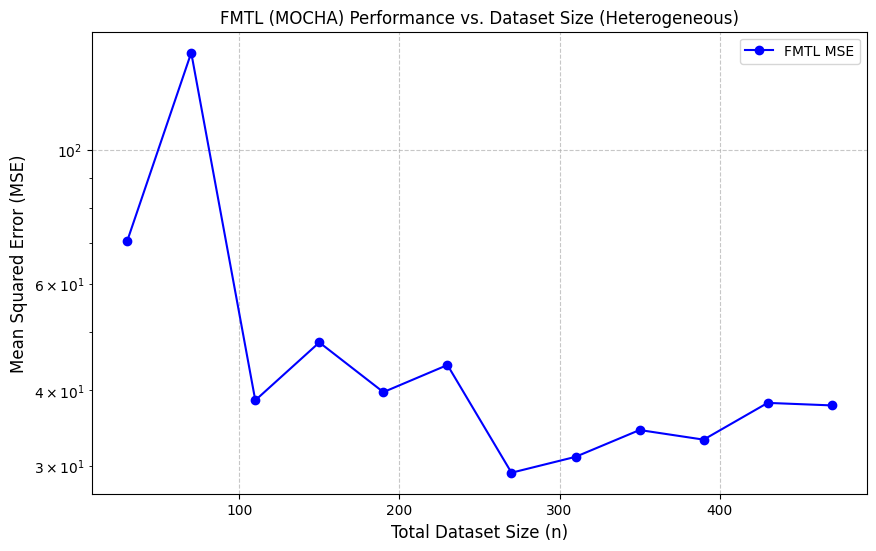

In [35]:
base_config = {
    'n': 1000,
    'events':200,
    'sensors': 10,
    'output_arity': 50,
    'noise_std': 0.01,
    'seed': 42
}

n_values = range(30, 500, 40)

fmtl_n_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='n',
    sweep_values=n_values
)

plot_results(
    x_values=n_values,
    y_values=fmtl_n_results,
    xlabel='Total Dataset Size (n)',
    title='FMTL (MOCHA) Performance vs. Dataset Size (Heterogeneous)',
    filename='FTML_datasetsize_heterogeneous.png'
)

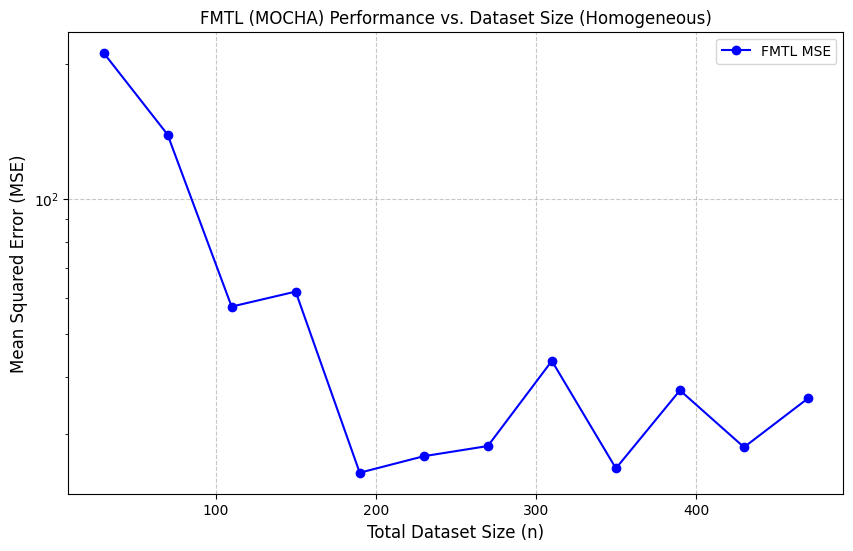

In [36]:
fmtl_n_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='n',
    sweep_values=n_values
)

plot_results(
    x_values=n_values,
    y_values=fmtl_n_results,
    xlabel='Total Dataset Size (n)',
    title='FMTL (MOCHA) Performance vs. Dataset Size (Homogeneous)',
    filename='FTML_datasetsize_homogeneous.png'
)

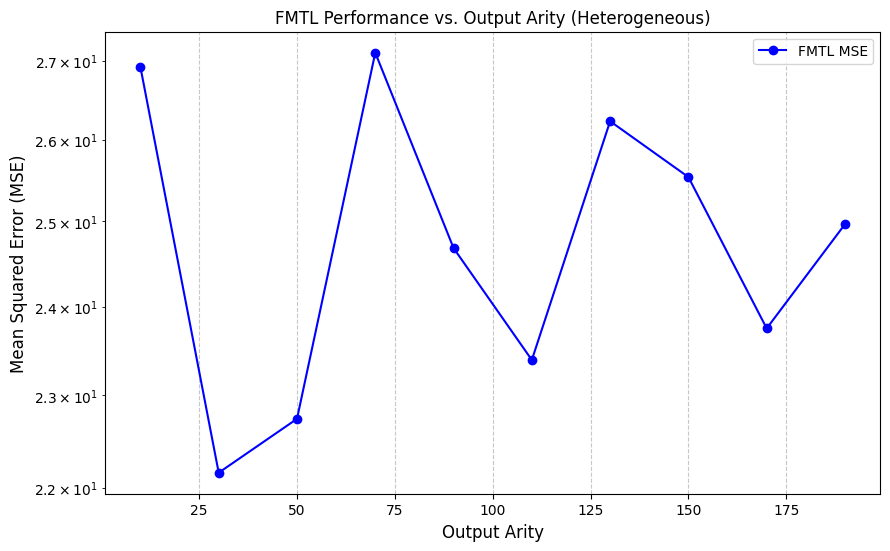

In [37]:
arity_values = range(10, 200, 20)

fmtl_arity_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='output_arity',
    sweep_values=arity_values
)

plot_results(
    x_values=arity_values,
    y_values=fmtl_arity_results,
    xlabel='Output Arity',
    title='FMTL Performance vs. Output Arity (Heterogeneous)',
    filename='FMTL_arity_heterogeneous.png'
)

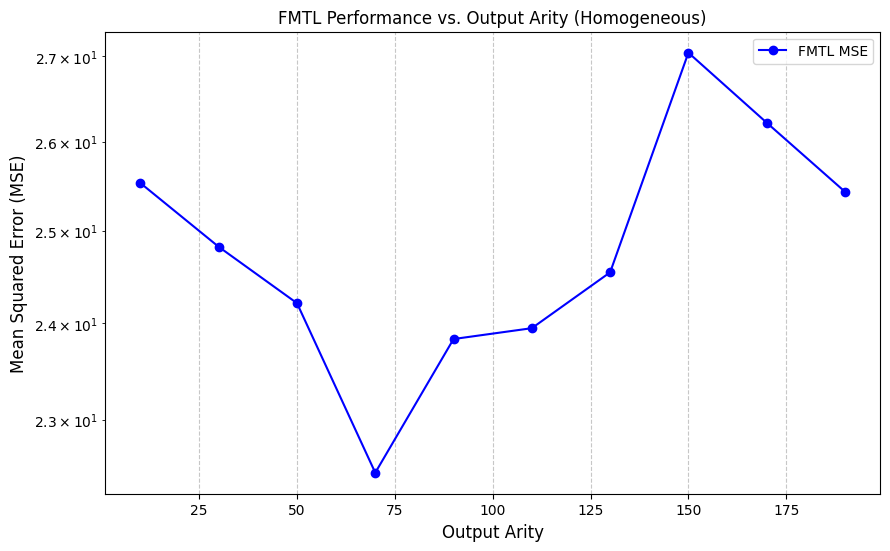

In [38]:
fmtl_arity_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='output_arity',
    sweep_values=arity_values
)

plot_results(
    x_values=arity_values,
    y_values=fmtl_arity_results,
    xlabel='Output Arity',
    title='FMTL Performance vs. Output Arity (Homogeneous)',
    filename='FMTL_arity_homogeneous.png'
)

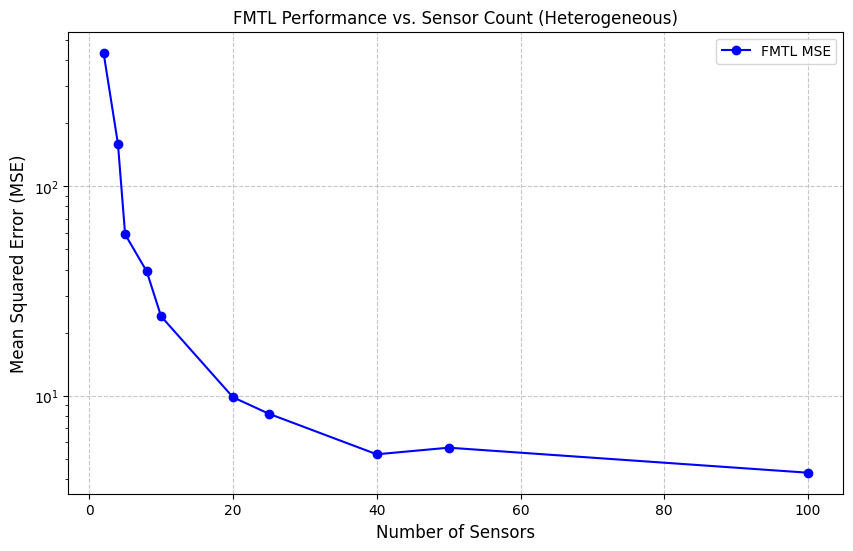

In [39]:
sensor_values = [2, 4, 5, 8, 10, 20, 25, 40, 50, 100]

fmtl_sensor_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL_Heterogeneous,
    base_params=base_config,
    sweep_key='sensors',            
    sweep_values=sensor_values
)

plot_results(
    x_values=list(sensor_values),   
    y_values=fmtl_sensor_results,
    xlabel='Number of Sensors',    
    title='FMTL Performance vs. Sensor Count (Heterogeneous)', 
    filename='FMTL_sensors_heterogeneous.png'
)

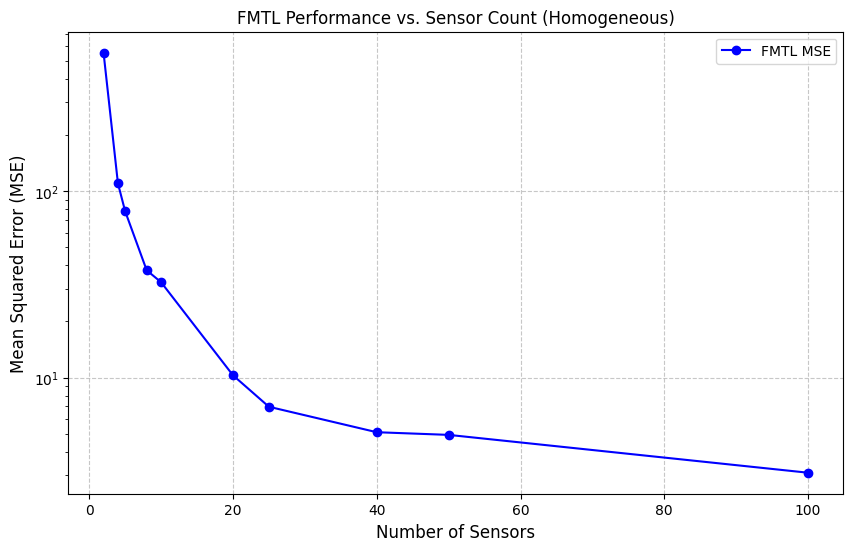

In [40]:
fmtl_sensor_results = sweep_parameter(
    eval_func=evaluate_fmtl_task,
    case_class=CaseHFL,
    base_params=base_config,
    sweep_key='sensors',            
    sweep_values=sensor_values
)

plot_results(
    x_values=list(sensor_values),   
    y_values=fmtl_sensor_results,
    xlabel='Number of Sensors',    
    title='FMTL Performance vs. Sensor Count (Homogeneous)', 
    filename='FMTL_sensors_homogeneous.png'
)